# Stage 1: Run a pretrained detector (an afternoon)
Goal: see what detection output looks like before learning how it works.

1. Run YOLO (yolo11n.pt, the smallest) on your test images with ultralytics
2. Draw boxes yourself with OpenCV/matplotlib from the raw results (don't just use .plot())
3. Print the raw outputs: boxes, class ids, confidences
4. Vary the confidence threshold (0.1, 0.25, 0.5, 0.75) and watch false positives/negatives change
5. Try a webcam or video file with the same model
Questions to answer:

What are the 80 COCO classes, and what happens with objects that aren't among them?
Where does it fail on your hard images, and why?
How does speed differ between yolo11n and yolo11m on your CPU?

In [4]:
from ultralytics import YOLO
from PIL import Image

In [5]:
model = YOLO("yolo11n.pt")

results = model("../images/1.jpg")


image 1/1 c:\Users\61417\Documents\misc_projects\image_analysis\notebooks\..\images\1.jpg: 448x640 1 bear, 222.0ms
Speed: 14.0ms preprocess, 222.0ms inference, 22.5ms postprocess per image at shape (1, 3, 448, 640)


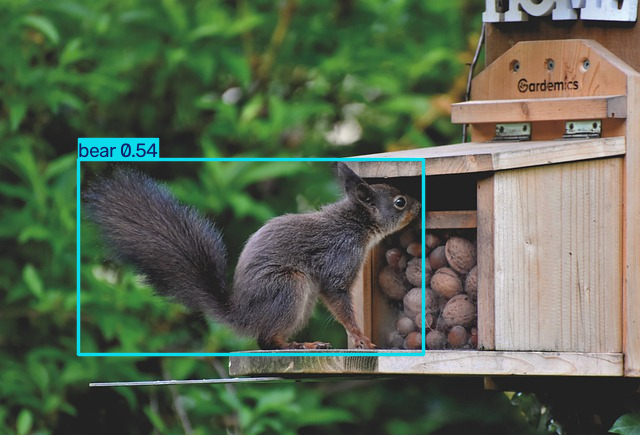

In [9]:
im_array = results[0].plot()
im = Image.fromarray(im_array[...,::-1])
display(im)

In [13]:
for result in results:
    boxes = result.boxes
    for box in boxes:
        conf = box.conf[0].item()
        cls = int(box.cls[0].item())
        class_name = model.names[cls]

        print(f"Object: {class_name}; Confidence: {conf:.2f}")

Object: bear; Confidence: 0.54


In [44]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([21.])
conf: tensor([0.5441])
data: tensor([[ 78.5602, 159.7870, 423.7845, 354.4808,   0.5441,  21.0000]])
id: None
is_track: False
orig_shape: (435, 640)
shape: torch.Size([1, 6])
xywh: tensor([[251.1724, 257.1339, 345.2242, 194.6938]])
xywhn: tensor([[0.3925, 0.5911, 0.5394, 0.4476]])
xyxy: tensor([[ 78.5602, 159.7870, 423.7845, 354.4808]])
xyxyn: tensor([[0.1228, 0.3673, 0.6622, 0.8149]])

In [11]:
results[0].names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

Looking at raw bounding box probs - Mouse is not viewed as being at all likely, but Bear is a bit likely. Apparently YOLO uses 1 Logit model per class rather than a sigmoid multi-class prediction

In [ ]:
import torch
boxes = results[0].boxes
# 1. Get the image array
orig_img = results[0].orig_img

# 2. Format properly: Reorder dimensions to [C, H, W], add batch dim, and normalize to 0.0-1.0
preprocessed_tensor = model.predictor.preprocess([orig_img])
# 3. Send to the same device as your model (CPU or CUDA)
img_tensor = preprocessed_tensor.to(model.device)

# 4. Run through the raw model
with torch.no_grad():
    raw_output = model.model(img_tensor)

predictions = raw_output[0].squeeze(0).T


for box in boxes:

    x1, y1, x2, y2 = box.xyxy[0]
    # first 4 entries are bounding box coords (?) then class scores
    all_class_scores = predictions[:, 4:]
    all_class_probs = torch.sigmoid(all_class_scores)

        # Find the row index where the max probability matches the box's highest conf index
    top_class_id = int(box.cls[0].item())
    
    # Filter anchors where this specific class is highly confident
    matched_anchor_idx = (all_class_probs[:, top_class_id] - box.conf[0]).abs().argmin()
    
    # Now you have the complete array of 80 class probabilities for THIS exact box!
    box_all_probs = all_class_probs[matched_anchor_idx]
    
    # Look up specific alternative classes
    bear_idx = model.names.index("bear") if "bear" in model.names else 21 
    mouse_idx = model.names.index("mouse") if "mouse" in model.names else 74
    
    print(f"Detected Box Match Conf: {box_all_probs[top_class_id].item():.4f}")
    print(f"--- Alternative Class Checks ---")
    print(f"Confidence if predicted Bear: {box_all_probs[bear_idx].item():.4f}")
    print(f"Confidence if predicted Mouse: {box_all_probs[mouse_idx].item():.4f}")


Detected Box Match Conf: 0.5404
--- Alternative Class Checks ---
Confidence if predicted Bear: 0.5404
Confidence if predicted Mouse: 0.5000


In [39]:
all_class_probs.size(), all_class_scores.size(), predictions.size()

(torch.Size([5880, 80]), torch.Size([5880, 80]), torch.Size([5880, 84]))

In [31]:
box_all_probs

tensor([0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5004, 0.5004, 0.5001, 0.5000, 0.5000, 0.5000, 0.5000, 0.5404, 0.5000, 0.5000, 0.5000, 0.5002, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
        0.5000, 0.5000])

In [27]:
predictions.size()

torch.Size([5880, 84])

## Predict on each of the images

Observations:
- model is pretty good out of the box but there are some quirks
- Some predictions cannot be made because the class doesn't exist (e.g. squirrel in first image)
- not all things are picked up (e.g. person in soldier hugging dog - possibly the camo or unusual circumstance?)
- Interesting that the lego person is recognised as a 'person' but the storm troopers aren't. Could the model rely on the presence of facial features?
- interesting some of the low probabilities of classes - is there a threshold set somewhere? (model.predictor.args.conf, default is 0.25)


Applying model to 1.jpg

image 1/1 c:\Users\61417\Documents\misc_projects\image_analysis\notebooks\..\images\1.jpg: 448x640 1 bear, 54.7ms
Speed: 1.6ms preprocess, 54.7ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)
Applying model to 10.jpg

image 1/1 c:\Users\61417\Documents\misc_projects\image_analysis\notebooks\..\images\10.jpg: 448x640 1 cup, 1 laptop, 1 book, 50.0ms
Speed: 2.7ms preprocess, 50.0ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)
Applying model to 2.jpg

image 1/1 c:\Users\61417\Documents\misc_projects\image_analysis\notebooks\..\images\2.jpg: 640x448 1 dog, 49.2ms
Speed: 1.5ms preprocess, 49.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 448)
Applying model to 3.jpg

image 1/1 c:\Users\61417\Documents\misc_projects\image_analysis\notebooks\..\images\3.jpg: 480x640 3 chairs, 91.2ms
Speed: 37.2ms preprocess, 91.2ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
Applying model to 4.jpg

image 1/1 

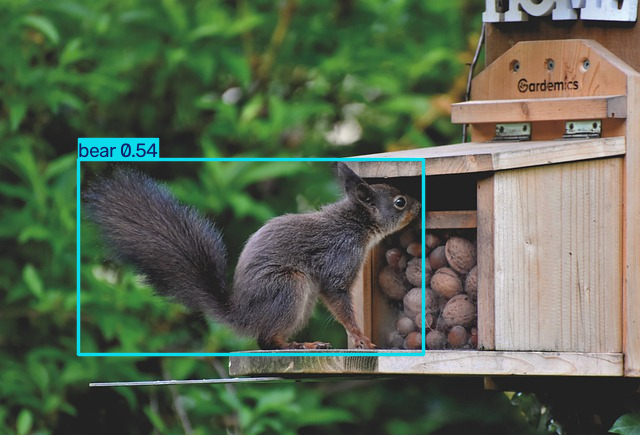

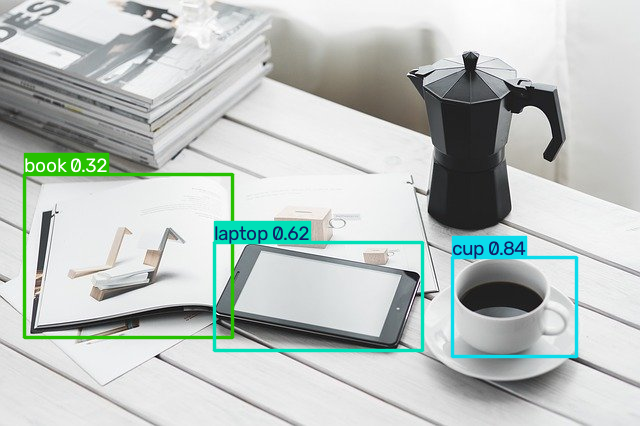

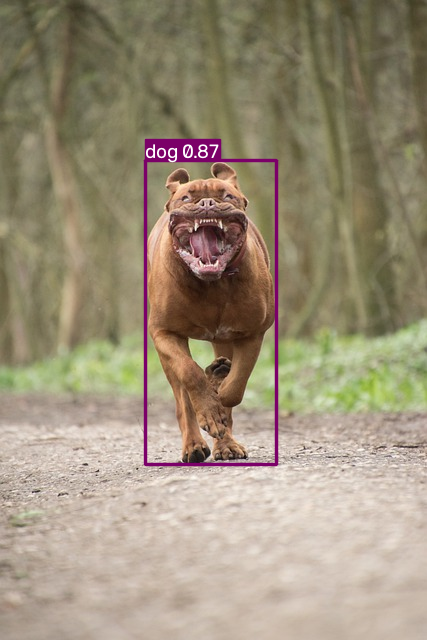

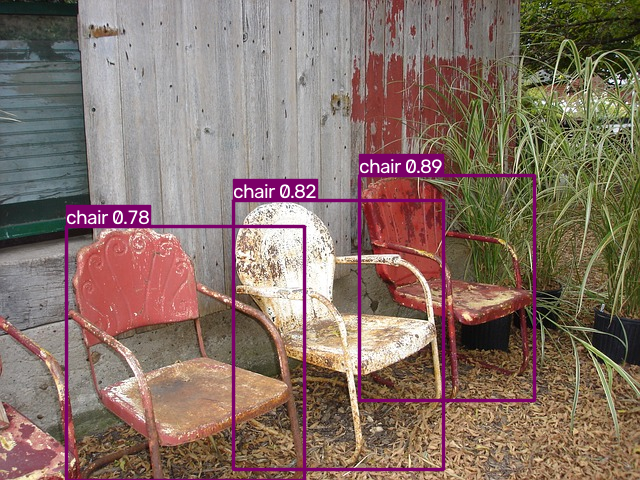

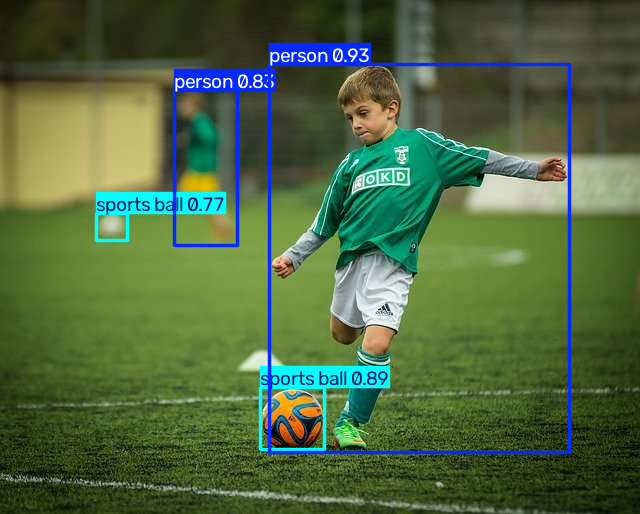

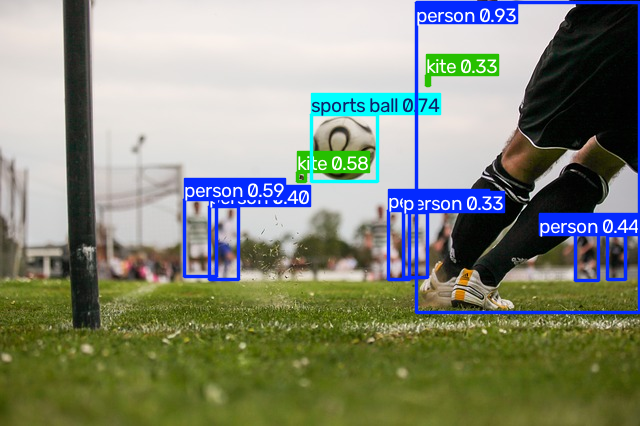

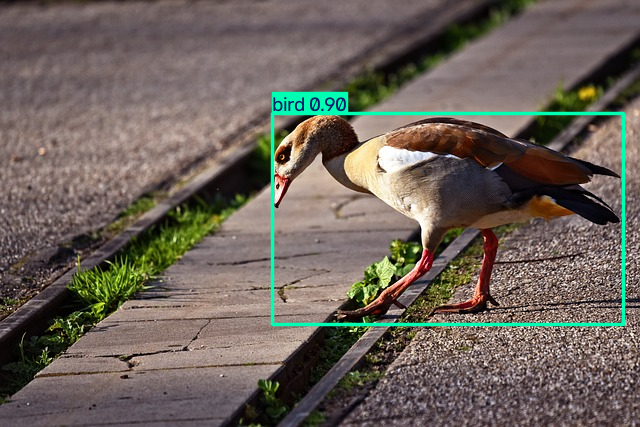

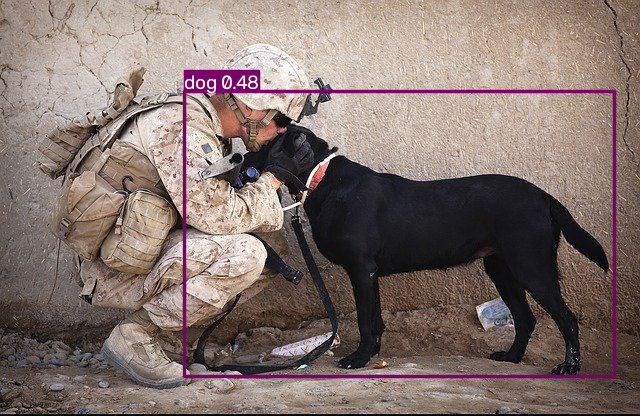

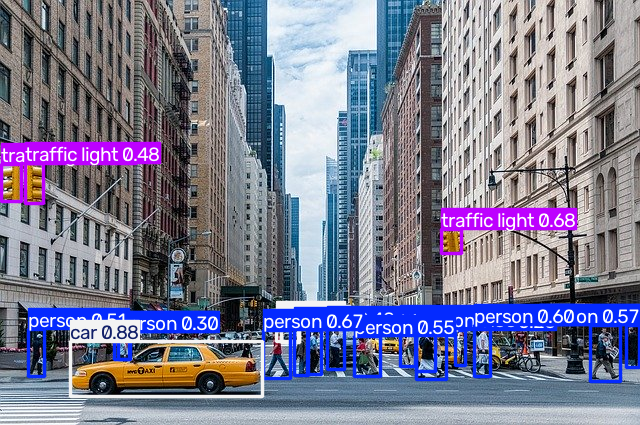

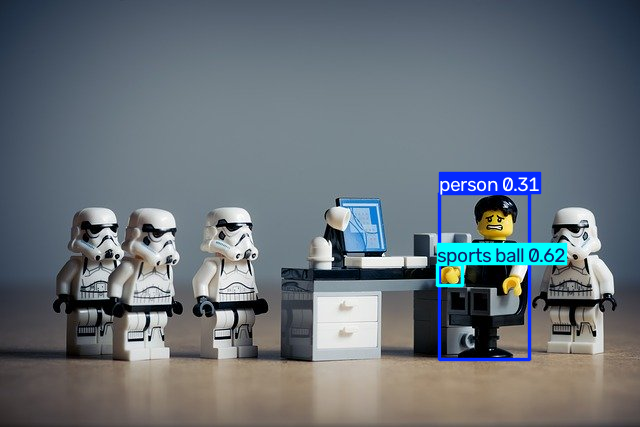

In [47]:
import os
model_to_use = "yolo11n.pt"
img_root = "../images/"

model = YOLO(model_to_use)
results = dict()

for _file in os.listdir(img_root):
    if '.jpg' in _file:
        print(f"Applying model to {_file}")
        results[_file] = model(img_root + _file)[0]

## naive plotting using builtins
for img_name, result in results.items():
    im_array = result.plot()
    im = Image.fromarray(im_array[...,::-1])
    display(im)

## Draw the bounding boxes and plot the images

Steps to plot the box:
- get all the boxes from the raw model output (first 4 entries - x centre, y centre, height (normalised), width (normalised))
- write a function to calculate the actual box

In [100]:
import cv2

def get_raw_model_outputs(model, img_file_loc):
    img = cv2.imread(img_file_loc)
    processed_img = model.predictor.preprocess([img])
    model.model.eval()
    with torch.no_grad():
        raw_output = model.model(processed_img)[0].squeeze(0).T
    bbox_vals = raw_output[:, :4]
    class_scores = raw_output[:, 4:]
    return bbox_vals, class_scores

def get_bbox_for_matplotlib_patch(bbox_vals):
    """
    Extract YOLO bbox values (centre x, centre y, height, width) to format for matplotlib plot
    ((x_min, y_min), width, height)
    """

    x_min = bbox_vals[:, 0] - bbox_vals[:, 3] / 2
    y_min = bbox_vals[:, 1] - bbox_vals[:, 2] / 2
    return [
        [
            (x_min[i].item(), y_min[i].item()), 
            bbox_vals[i, 3].item(), 
            bbox_vals[i, 2].item()
        ] for i in range(bbox_vals.size(0)) 
    ]
    


In [101]:
img = cv2.imread(img_root + "1.jpg")
bbox_vals, class_scores = get_raw_model_outputs(model, img_root + "1.jpg")

bbox_for_plot = get_bbox_for_matplotlib_patch(bbox_vals=bbox_vals)

In [106]:

box_confidences, class_ids = torch.max(class_scores, dim=1)

# Example: Print a candidate box that passes a standard threshold
thresh = 0.25
for idx in range(len(box_confidences)):
    conf = box_confidences[idx].item()
    if conf > thresh:
        cls_id = class_ids[idx].item()
        name = model.names[cls_id]
        print(f"Anchor Index {idx} -> Class: {name}, Confidence: {conf:.4f}")


Anchor Index 5746 -> Class: bear, Confidence: 0.5441
Anchor Index 5747 -> Class: bear, Confidence: 0.4935
Anchor Index 5748 -> Class: bear, Confidence: 0.4636
Anchor Index 5766 -> Class: bear, Confidence: 0.4798
Anchor Index 5767 -> Class: bear, Confidence: 0.4389
Anchor Index 5768 -> Class: bear, Confidence: 0.4040
Anchor Index 5786 -> Class: bear, Confidence: 0.3880
Anchor Index 5787 -> Class: bear, Confidence: 0.4999
Anchor Index 5788 -> Class: bear, Confidence: 0.3731


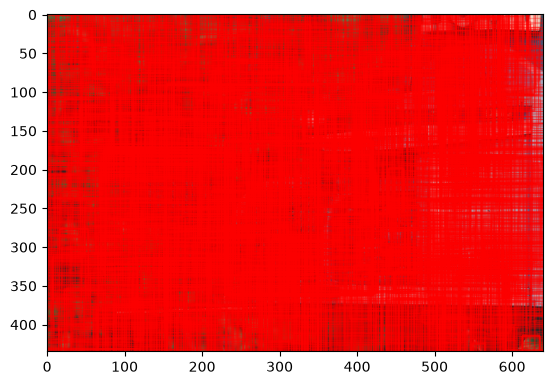

In [90]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots()

ax.imshow(img)

## doing this shows the need for non-maximum suppression!!
for bbox in bbox_for_plot:
    rect = patches.Rectangle(
        bbox[0],
        bbox[1],
        bbox[2],
        linewidth=1,
        edgecolor='r',
        facecolor='none',
        alpha = 0.3
    )
    ax.add_patch(rect)

plt.show()